# Spatio-Temporal Classification of Urban Crime Types in the United Kingdom Using Supervised Machine Learning

This notebook implements a beginner-friendly machine learning pipeline for the approved UK crime classification project using open police data from the Metropolitan Police area.

**Main scope:** temporal + spatial features, class imbalance handling, multi-class classification, evaluation, and interpretability.

**Out of scope for the main pipeline:** Office for National Statistics (ONS) socio-economic covariates. These are reserved for future work only.

## 1. Notebook plan

1. Load CSV(s) exported from the UK Police open data portal.
2. Clean and inspect the data.
3. Exploratory Data Analysis (EDA).
4. Create temporal and spatial features.
5. Prepare feature sets for hypothesis testing (H2: raw lat/lon vs aggregated).
6. Train-test split (temporal).
7. Compute naive baselines (H1: random and majority-class).
8. Train and evaluate classifiers (Logistic Regression, Random Forest, XGBoost).
9. Class imbalance experiment (H3: SMOTE / RandomOverSampler).
10. Confusion matrices for all models.
11. Feature importance and interpretability.
12. Save outputs.

In [1]:
# Install dependencies (Colab only; safe to rerun)
# !pip install -q scikit-learn imbalanced-learn xgboost shap

import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_sample_weight

from imblearn.over_sampling import SMOTE, RandomOverSampler

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception:
    XGBOOST_AVAILABLE = False

try:
    import shap
    SHAP_AVAILABLE = True
except Exception:
    SHAP_AVAILABLE = False


try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
    PYTORCH_AVAILABLE = True
except Exception:
    PYTORCH_AVAILABLE = False

print('PyTorch available:', PYTORCH_AVAILABLE)

print('XGBoost available:', XGBOOST_AVAILABLE)
print('SHAP available:', SHAP_AVAILABLE)

PyTorch available: True
XGBoost available: True
SHAP available: True


## 2. Data loading

Upload or mount a CSV containing UK Police street-level crime records for the Metropolitan Police area.

Expected columns may include: `month`, `category` or `crime_type`, `latitude`, `longitude`, `location type`, and optionally `lsoa_code`.

If your column names differ, the helper cells below try to detect them automatically.

In [2]:
# Run this cell if your archive has been uploaded to Google Drive (Colab only)

# Load the Drive helper and mount
from google.colab import drive
drive.mount('/content/drive')

# Make a copy of the folder's zip contents into Colab's root "/content" folder.
!cp "/content/drive/MyDrive/Colab Notebooks/urban_crime/"*.zip /content

!ls /content

Mounted at /content/drive
drive  mps_crime_data.zip  sample_data


In [3]:
import zipfile
import glob

# ── CHANGE THESE TWO LINES ONLY ──────────────────────────────────────────────
ZIP_PATH      = '/content/mps_crime_data.zip'   # Modify the ZIP file path accordingly
MONTH_FOLDERS = [                               # Select the folder(s) to use in the archive using the "yyyy-mm" format
    '2025-01', '2025-02', '2025-03',
    '2025-04', '2025-05', '2025-06',
    '2025-07', '2025-08', '2025-09',
    '2025-10', '2025-11', '2025-12'
    ]
# ─────────────────────────────────────────────────────────────────────────────

if not os.path.exists(ZIP_PATH):
    raise FileNotFoundError(f'Zip not found: {ZIP_PATH}')

EXTRACT_DIR = '/content/crime_data_extracted'
monthly_dfs = []

with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
    all_files = zf.namelist()

    for MONTH_FOLDER in MONTH_FOLDERS:
        target_files = [
            f for f in all_files
            if f.startswith(MONTH_FOLDER + '/') and f.endswith('.csv')
        ]

        if not target_files:
            print(f'WARNING: No CSV found for {MONTH_FOLDER} — skipping.')
            continue

        for f in target_files:
            zf.extract(f, EXTRACT_DIR)

        csv_pattern = f'{EXTRACT_DIR}/{MONTH_FOLDER}/*-street.csv'
        matches = glob.glob(csv_pattern)
        if not matches:
            matches = glob.glob(f'{EXTRACT_DIR}/{MONTH_FOLDER}/*.csv')

        if matches:
            monthly_dfs.append(pd.read_csv(matches[0]))
            print(f'Loaded: {MONTH_FOLDER}  ({len(monthly_dfs[-1]):,} rows)')
        else:
            print(f'WARNING: CSV extracted but not found at {csv_pattern}')

if not monthly_dfs:
    raise ValueError('No monthly CSVs were loaded. Check ZIP_PATH and MONTH_FOLDERS.')

df = pd.concat(monthly_dfs, ignore_index=True)
print(f'\nCombined DataFrame: {df.shape[0]:,} rows across {len(monthly_dfs)} months')
df.head()

Loaded: 2025-01  (86,952 rows)
Loaded: 2025-02  (83,660 rows)
Loaded: 2025-03  (93,571 rows)
Loaded: 2025-04  (93,211 rows)
Loaded: 2025-05  (99,386 rows)
Loaded: 2025-06  (100,914 rows)
Loaded: 2025-07  (106,677 rows)
Loaded: 2025-08  (99,050 rows)
Loaded: 2025-09  (93,280 rows)
Loaded: 2025-10  (98,545 rows)
Loaded: 2025-11  (94,209 rows)
Loaded: 2025-12  (90,961 rows)

Combined DataFrame: 1,140,416 rows across 12 months


,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Last outcome category,Context
0,4af53e255f9f3e69d1a295a288fe02488234842b18020e...,2025-01,Metropolitan Police Service,Metropolitan Police Service,-0.549537,50.815808,On or near Peel Close,E01031427,Arun 004A,Violence and sexual offences,Status update unavailable,NaN
1,af818ffc133013b72feaea4adead5a76c76aee204b98d4...,2025-01,Metropolitan Police Service,Metropolitan Police Service,0.884518,51.128775,On or near East Stour Way,E01032817,Ashford 009G,Other theft,Status update unavailable,NaN
2,NaN,2025-01,Metropolitan Police Service,Metropolitan Police Service,0.138830,51.583433,On or near Thatches Grove,E01000027,Barking and Dagenham 001A,Anti-social behaviour,NaN,NaN
3,NaN,2025-01,Metropolitan Police Service,Metropolitan Police Service,0.140194,51.582356,On or near Hatch Grove,E01000027,Barking and Dagenham 001A,Anti-social behaviour,NaN,NaN
4,NaN,2025-01,Metropolitan Police Service,Metropolitan Police Service,0.138830,51.583433,On or near Thatches Grove,E01000027,Barking and Dagenham 001A,Anti-social behaviour,NaN,NaN


In [4]:
# Standardise column names to lowercase for easier handling
df.columns = [c.strip().lower() for c in df.columns]

# Common candidate names in police data
TARGET_CANDIDATES   = ['category', 'crime type', 'crime_type', 'crime category', 'crimecategory']
DATE_CANDIDATES     = ['month', 'date', 'reported_month']
LAT_CANDIDATES      = ['latitude', 'lat']
LON_CANDIDATES      = ['longitude', 'lon', 'lng']
LSOA_CANDIDATES     = ['lsoa_code', 'lsoa', 'lsoa code']

# IMPORTANT: 'location type' and 'location_type' are checked BEFORE bare 'location'
# to avoid matching the free-text street name column (e.g. "On or near Thatches Grove")
LOCTYPE_CANDIDATES  = ['location type', 'location_type']   # categorical (~10-15 unique values)
LOCNAME_CANDIDATES  = ['location']                          # free-text street name (excluded from features)

def first_existing(candidates, columns):
    for c in candidates:
        if c in columns:
            return c
    return None

target_col   = first_existing(TARGET_CANDIDATES, df.columns)
date_col     = first_existing(DATE_CANDIDATES, df.columns)
lat_col      = first_existing(LAT_CANDIDATES, df.columns)
lon_col      = first_existing(LON_CANDIDATES, df.columns)
lsoa_col     = first_existing(LSOA_CANDIDATES, df.columns)
loctype_col  = first_existing(LOCTYPE_CANDIDATES, df.columns)   # the categorical feature we want
locname_col  = first_existing(LOCNAME_CANDIDATES, df.columns)   # the free-text field we exclude

print('Detected target column:       ', target_col)
print('Detected date column:         ', date_col)
print('Detected latitude column:     ', lat_col)
print('Detected longitude column:    ', lon_col)
print('Detected LSOA column:         ', lsoa_col)
print('Detected location type column:', loctype_col)
print('Detected location name column:', locname_col, '(excluded from features)')

Detected target column:        crime type
Detected date column:          month
Detected latitude column:      latitude
Detected longitude column:     longitude
Detected LSOA column:          lsoa code
Detected location type column: None
Detected location name column: location (excluded from features)


## 3. Basic cleaning

We keep the cleaning process simple and transparent because this is a beginner-friendly project.

In [5]:
# Check all essential columns are present
required = [c for c in [target_col, date_col, lat_col, lon_col] if c is not None]
if len(required) < 4:
    raise ValueError('The dataset is missing one or more essential columns. Check the detected column names above.')

# Drop rows with missing values in essential columns
df = df.dropna(subset=required).copy()

# Parse the date column into datetime data type and drop invalid entries
df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
df = df.dropna(subset=[date_col]).copy()

# Keep only reasonable coordinate values
df = df[(df[lat_col].between(-90, 90)) & (df[lon_col].between(-180, 180))].copy()

print('Cleaned shape:', df.shape)
df[[target_col, date_col, lat_col, lon_col]].head()

Cleaned shape: (1140416, 12)


,crime type,month,latitude,longitude
0,Violence and sexual offences,2025-01-01,50.815808,-0.549537
1,Other theft,2025-01-01,51.128775,0.884518
2,Anti-social behaviour,2025-01-01,51.583433,0.138830
3,Anti-social behaviour,2025-01-01,51.582356,0.140194
4,Anti-social behaviour,2025-01-01,51.583433,0.138830


## 4. Exploratory Data Analysis (EDA)

The monthly chart addresses H1 visually. The heatmap shows how different crime types vary across months — the temporal dimension central to this research.

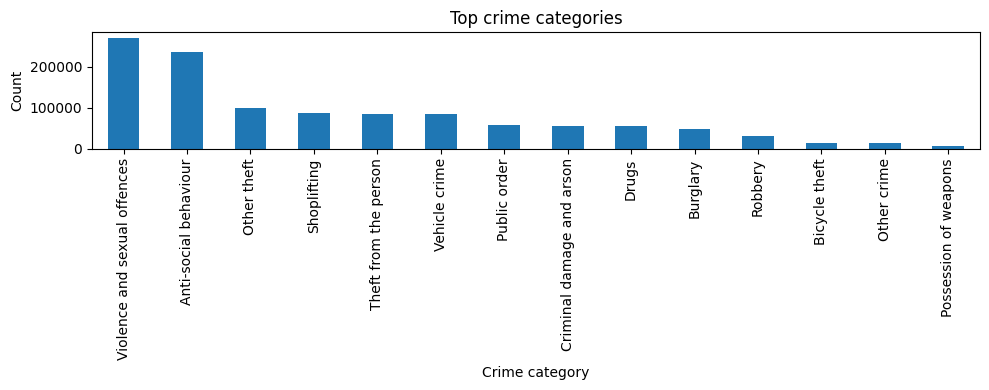

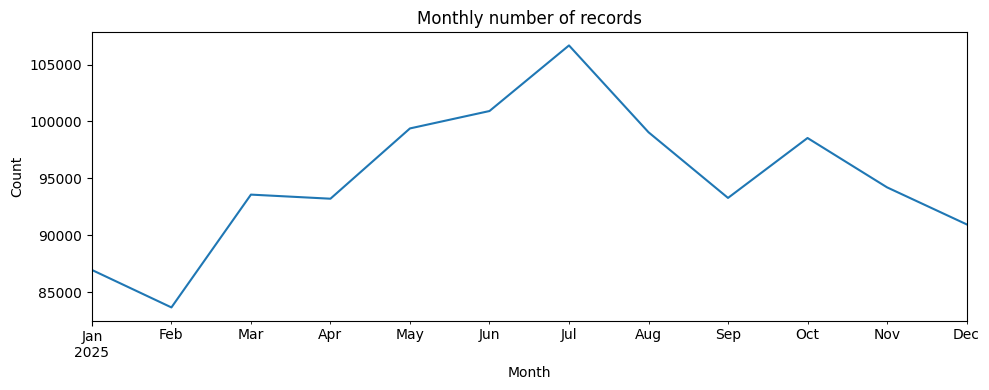

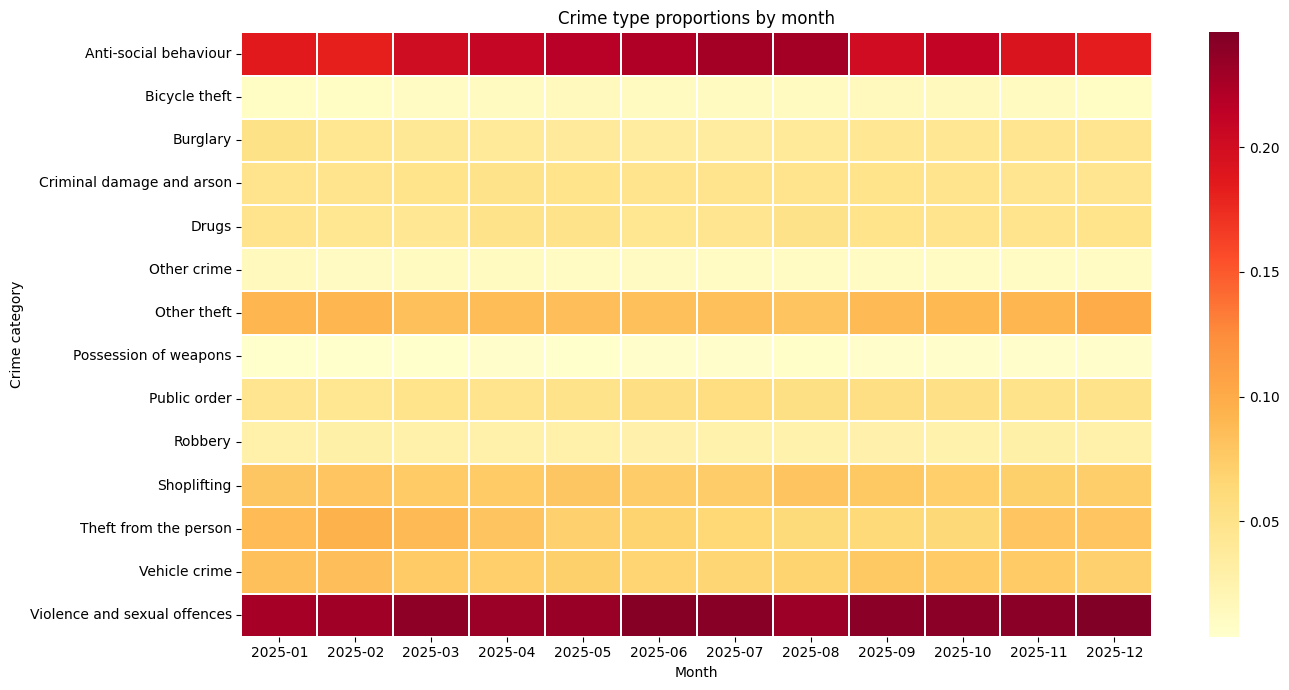

In [6]:
# 4a. Crime type distribution
plt.figure(figsize=(10, 4))
df[target_col].value_counts().head(15).plot(kind='bar')
plt.title('Top crime categories')
plt.xlabel('Crime category')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# 4b. Monthly record counts
monthly_counts = df.groupby(df[date_col].dt.to_period('M')).size()
plt.figure(figsize=(10, 4))
monthly_counts.plot()
plt.title('Monthly number of records')
plt.xlabel('Month')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# 4c. Crime type × Month heatmap (visual support for H1)
df['_month_label'] = df[date_col].dt.to_period('M').astype(str)
ct_month = pd.crosstab(df[target_col], df['_month_label'])
ct_month = ct_month.div(ct_month.sum(axis=0), axis=1)  # normalise to proportions per month

plt.figure(figsize=(14, 7))
sns.heatmap(ct_month, cmap='YlOrRd', linewidths=0.3, annot=False)
plt.title('Crime type proportions by month')
plt.xlabel('Month')
plt.ylabel('Crime category')
plt.tight_layout()
plt.show()

df.drop(columns=['_month_label'], inplace=True)

## 5. Feature engineering

Because the dataset is monthly street-level crime data, the main temporal features are derived from the `month` field. If a time-of-day field is unavailable, we use the information that is actually present and keep the feature set honest.

Key features engineered:
- **Temporal:** `month_sin`, `month_cos` (cyclical encoding so Dec↔Jan are adjacent), `month_num_sq` (seasonal curvature), `quarter`, `season`
- **Spatial:** `spatial_feature` from LSOA codes or grid binning (H2)
- **Location type:** categorical field (~10–15 values) if available

In [7]:
# ── Temporal features ─────────────────────────────────────────────────────────
df['year']      = df[date_col].dt.year
df['month_num'] = df[date_col].dt.month
df['quarter']   = df[date_col].dt.quarter
df['year_month'] = df[date_col].dt.to_period('M').astype(str)

# Cyclical month encoding — ensures December (12) and January (1) are treated
# as adjacent rather than maximally distant. Uses sine/cosine transformation.
df['month_sin'] = np.sin(2 * np.pi * df['month_num'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month_num'] / 12)

# Squared month term — helps capture seasonal curvature (e.g. mid-year peaks)
df['month_num_sq'] = df['month_num'] ** 2

# Simple season mapping
season_map = {12: 'winter', 1: 'winter', 2: 'winter',
              3: 'spring', 4: 'spring', 5: 'spring',
              6: 'summer', 7: 'summer', 8: 'summer',
              9: 'autumn', 10: 'autumn', 11: 'autumn'}
df['season'] = df['month_num'].map(season_map)

# ── Spatial features (H2) ────────────────────────────────────────────────────
# Uses LSOA if available, otherwise coarse grid binning
if lsoa_col is not None:
    df['spatial_feature'] = df[lsoa_col].astype(str)
    spatial_mode = 'lsoa'
else:
    grid_size = 0.01  # Groups geo-coordinates into grids of ~1km squares
    df['x_bin'] = (df[lon_col] // grid_size).astype('int64')
    df['y_bin'] = (df[lat_col] // grid_size).astype('int64')
    df['spatial_feature'] = df['x_bin'].astype(str) + '_' + df['y_bin'].astype(str)
    spatial_mode = 'grid'

print('Spatial mode:', spatial_mode)
print('Sample features:')
df[['year', 'month_num', 'month_sin', 'month_cos', 'month_num_sq',
    'quarter', 'season', 'spatial_feature']].head()

Spatial mode: lsoa
Sample features:


,year,month_num,month_sin,month_cos,month_num_sq,quarter,season,spatial_feature
0,2025,1,0.5,0.866025,1,1,winter,E01031427
1,2025,1,0.5,0.866025,1,1,winter,E01032817
2,2025,1,0.5,0.866025,1,1,winter,E01000027
3,2025,1,0.5,0.866025,1,1,winter,E01000027
4,2025,1,0.5,0.866025,1,1,winter,E01000027


In [8]:
# ── Target encoding ───────────────────────────────────────────────────────────
work_df = df.copy()
work_df['target'] = work_df[target_col].astype(str)

# Optional grouping of rare labels to keep the problem manageable
min_class_count = 100
counts = work_df['target'].value_counts()
common_labels = counts[counts >= min_class_count].index
work_df['target_grouped'] = work_df['target'].where(work_df['target'].isin(common_labels), 'other')

label_encoder = LabelEncoder()
work_df['y'] = label_encoder.fit_transform(work_df['target_grouped'])

# ── Spatial encoding with frequency-based collapsing ─────────────────────────
# Rare LSOA codes are collapsed into a single "RARE" bucket before encoding.
# This reduces noise from sparse spatial cells and mitigates the risk of LSOA
# codes appearing in the test set that were never seen during training.
MIN_LSOA_COUNT = 20
lsoa_counts = work_df['spatial_feature'].value_counts()
common_lsoas = lsoa_counts[lsoa_counts >= MIN_LSOA_COUNT].index
rare_rows = (~work_df['spatial_feature'].isin(common_lsoas)).sum()
work_df['spatial_feature'] = work_df['spatial_feature'].where(
    work_df['spatial_feature'].isin(common_lsoas), 'RARE'
)
print(f'Collapsed {rare_rows:,} rows with rare LSOA codes (count<{MIN_LSOA_COUNT}) into "RARE" bucket')
print(f'Unique spatial values after collapsing: {work_df["spatial_feature"].nunique():,}')

spatial_encoder = LabelEncoder()
work_df['spatial_enc'] = spatial_encoder.fit_transform(work_df['spatial_feature'].astype(str))

# ── Season encoding ──────────────────────────────────────────────────────────
season_encoder = LabelEncoder()
work_df['season_enc'] = season_encoder.fit_transform(work_df['season'])

# ── Location type encoding ───────────────────────────────────────────────────
# Only encode if it's the categorical location type field (~10-15 unique values),
# NOT the free-text street name (~38,000+ unique values)
loctype_enc_included = False
if loctype_col is not None:
    n_unique = work_df[loctype_col].nunique()
    if n_unique <= 50:  # safety guard — location type should have ~10-15 values
        work_df['loctype_enc'] = LabelEncoder().fit_transform(work_df[loctype_col].astype(str))
        loctype_enc_included = True
        print(f'Location type encoded: {n_unique} unique values from column "{loctype_col}"')
    else:
        print(f'WARNING: "{loctype_col}" has {n_unique} unique values — likely free-text, excluded.')

# ── Build feature column list ────────────────────────────────────────────────
feature_cols = ['month_sin', 'month_cos', 'month_num_sq', 'quarter', 'season_enc', 'spatial_enc']

# Conditionally include year only when the dataset spans multiple calendar years
if work_df['year'].nunique() > 1:
    feature_cols.append('year')
    print(f'year added to features — multiple years detected: {sorted(work_df["year"].unique())}')
else:
    print(f'year excluded from features — only one year in dataset: {work_df["year"].unique()[0]}')

if loctype_enc_included:
    feature_cols.append('loctype_enc')

print('\nTarget classes:', list(label_encoder.classes_))
print('Feature columns:', feature_cols)

Collapsed 5,659 rows with rare LSOA codes (count<20) into "RARE" bucket
Unique spatial values after collapsing: 4,987
year excluded from features — only one year in dataset: 2025

Target classes: ['Anti-social behaviour', 'Bicycle theft', 'Burglary', 'Criminal damage and arson', 'Drugs', 'Other crime', 'Other theft', 'Possession of weapons', 'Public order', 'Robbery', 'Shoplifting', 'Theft from the person', 'Vehicle crime', 'Violence and sexual offences']
Feature columns: ['month_sin', 'month_cos', 'month_num_sq', 'quarter', 'season_enc', 'spatial_enc']


## 5b. Feature sets for H2 comparison

H2 hypothesises that spatial aggregation (LSOA/grid binning) improves classification over raw latitude/longitude.

To test this, we build two feature sets sharing the same temporal features but differing in spatial representation:
- **Set A (raw):** uses raw latitude and longitude directly
- **Set B (aggregated):** uses `spatial_enc` (LSOA or grid) — the primary feature set

In [9]:
# Temporal features shared by both sets (everything except spatial_enc)
temporal_features = [c for c in feature_cols if c != 'spatial_enc']

# Set A: raw lat/lon (H2 comparison)
feature_cols_raw = temporal_features + [lat_col, lon_col]

# Set B: aggregated spatial (primary — already in feature_cols)
feature_cols_agg = feature_cols  # includes spatial_enc

print('H2 Set A (raw lat/lon) features:', feature_cols_raw)
print('H2 Set B (aggregated)   features:', feature_cols_agg)

H2 Set A (raw lat/lon) features: ['month_sin', 'month_cos', 'month_num_sq', 'quarter', 'season_enc', 'latitude', 'longitude']
H2 Set B (aggregated)   features: ['month_sin', 'month_cos', 'month_num_sq', 'quarter', 'season_enc', 'spatial_enc']


## 6. Train-test split

A temporal split is more realistic than a random split because it tests whether the model can generalise to later periods.
A random split would produce data leakage for time-ordered data, thereby misrepresenting how the model would perform during deployment.

In [10]:
# Sort by date and split by time
work_df = work_df.sort_values(date_col).reset_index(drop=True)
cutoff_date = work_df[date_col].quantile(0.8)
train_df = work_df[work_df[date_col] <= cutoff_date].copy()
test_df  = work_df[work_df[date_col] >  cutoff_date].copy()

# ── Fix remaining spatial leakage: remap unseen spatial codes to a sentinel ──
# Any LSOA code that appears in the test period but never during training is
# replaced with a single sentinel value (-1). This ensures the model encounters
# a consistent, known value for all novel spatial cells, rather than arbitrary
# integers it has never learned from.
train_spatial_set = set(train_df['spatial_enc'].unique())
unseen_mask = ~test_df['spatial_enc'].isin(train_spatial_set)
unseen_count = int(unseen_mask.sum())
UNSEEN_SENTINEL = -1
test_df.loc[unseen_mask, 'spatial_enc'] = UNSEEN_SENTINEL
print(f'Remapped {unseen_count:,} test rows ({100*unseen_count/len(test_df):.2f}%) '
      f'with unseen spatial codes to sentinel {UNSEEN_SENTINEL}')

# Primary feature sets (aggregated spatial — Set B)
X_train = train_df[feature_cols_agg]
y_train = train_df['y']
X_test  = test_df[feature_cols_agg]
y_test  = test_df['y']

# H2 comparison feature sets (raw lat/lon — Set A)
X_train_raw = train_df[feature_cols_raw]
X_test_raw  = test_df[feature_cols_raw]

print('\nTrain shape:', X_train.shape)
print('Test shape: ', X_test.shape)
print(f'Train period: {train_df[date_col].min().date()} to {train_df[date_col].max().date()}')
print(f'Test period:  {test_df[date_col].min().date()} to {test_df[date_col].max().date()}')

Remapped 0 test rows (0.00%) with unseen spatial codes to sentinel -1

Train shape: (955246, 6)
Test shape:  (185170, 6)
Train period: 2025-01-01 to 2025-10-01
Test period:  2025-11-01 to 2025-12-01


## Diagnostic checks

In [11]:
# ── DIAGNOSTIC CELL — run once before any model training ──────────────────

# 1. Spatial leakage — unseen bins in test set
train_spatial = set(train_df['spatial_enc'].unique())
test_spatial  = set(test_df['spatial_enc'].unique())
unseen        = test_spatial - train_spatial
print(f'[1] Unseen spatial bins in test: {len(unseen)} of {len(test_spatial)} '
      f'({100*len(unseen)/len(test_spatial):.1f}%)')

# 2. Label consistency — y ranges must match
print(f'\n[2] Train y range : {y_train.min()} – {y_train.max()}')
print(f'    Test  y range : {y_test.min()}  – {y_test.max()}')
print(f'    Classes known : {list(label_encoder.classes_)}')

# 3. Class distribution after grouping — watch for an oversized "other"
print(f'\n[3] Target distribution after grouping:')
print(work_df['target_grouped'].value_counts().to_string())

# 4. Feature variance — zero variance means a feature is useless
print(f'\n[4] Unique values per feature column (should all be > 1):')
print(X_train[feature_cols_agg].nunique().to_string())
print(f'\n    Feature summary:')
print(X_train[feature_cols_agg].describe().to_string())

# 5. H2 feature sets built correctly
print(f'\n[5] H2 Set A (raw) columns: {list(X_train_raw.columns)}')
print(f'    H2 Set B (agg) columns: {list(X_train.columns)}')

print('\n── End of diagnostics ──')

[1] Unseen spatial bins in test: 0 of 4987 (0.0%)

[2] Train y range : 0 – 13
    Test  y range : 0  – 13
    Classes known : ['Anti-social behaviour', 'Bicycle theft', 'Burglary', 'Criminal damage and arson', 'Drugs', 'Other crime', 'Other theft', 'Possession of weapons', 'Public order', 'Robbery', 'Shoplifting', 'Theft from the person', 'Vehicle crime', 'Violence and sexual offences']

[3] Target distribution after grouping:
target_grouped
Violence and sexual offences    270115
Anti-social behaviour           234967
Other theft                     100244
Shoplifting                      86774
Theft from the person            85420
Vehicle crime                    84205
Public order                     58302
Criminal damage and arson        54681
Drugs                            54025
Burglary                         47684
Robbery                          31332
Bicycle theft                    13826
Other crime                      13149
Possession of weapons             5692

[4] Uni

## 7a. Naive baselines (H1)

H1 requires showing that supervised models perform significantly better than:
- A **random baseline** (predicting a class drawn uniformly at random)
- A **majority-class baseline** (always predicting the most common crime type)

In [12]:
# Random baseline — predict a random class for every test row
np.random.seed(42)
n_classes = len(label_encoder.classes_)
y_pred_random = np.random.randint(0, n_classes, size=len(y_test))
random_f1 = f1_score(y_test, y_pred_random, average='macro')

# Majority-class baseline — always predict the most frequent class
majority_class = y_train.value_counts().idxmax()
y_pred_majority = np.full(len(y_test), majority_class)
majority_f1 = f1_score(y_test, y_pred_majority, average='macro')

print(f'Random baseline       macro F1: {random_f1:.4f}')
print(f'Majority-class baseline macro F1: {majority_f1:.4f}')
print(f'\nMajority class: "{label_encoder.inverse_transform([majority_class])[0]}" '
      f'({(y_train == majority_class).sum():,} of {len(y_train):,} training rows)')

Random baseline       macro F1: 0.0598
Majority-class baseline macro F1: 0.0279

Majority class: "Violence and sexual offences" (225,122 of 955,246 training rows)


## 7b. Supervised models

**Note** — For each model:
- **Precision:** "Of all the incidents the model labelled (*e.g. Anti-social behaviour*), how many were correct?"
- **Recall:** "Of all actual (*e.g. Anti-social behaviour*) incidents, how many did the model catch?"
- **F1-Score:** The *harmonic* mean of Precision and Recall. Unlike a simple average, the harmonic mean penalises imbalance — a model that scores 0.9 precision but 0.1 recall gets an F1 of 0.18 rather than 0.50, reflecting that one metric being very low undermines the other.

In [13]:
# ── Logistic Regression (aggregated spatial features) ─────────────────────────
# StandardScaler ensures all features have similar magnitudes, which is
# important for LR since it is sensitive to feature scale.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)      # fit on training data only
X_test_scaled  = scaler.transform(X_test)            # apply same transformation to test data

lr = LogisticRegression(
    solver='saga',            # Stochastic solver — faster on large datasets
    max_iter=500,
    tol=1e-4,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42,
    multi_class='multinomial'
)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

lr_f1 = f1_score(y_test, y_pred_lr, average='macro')
print(f'Logistic Regression macro F1: {lr_f1:.4f}')
print()
print(classification_report(y_test, y_pred_lr, target_names=label_encoder.classes_))

Logistic Regression macro F1: 0.0285

                              precision    recall  f1-score   support

       Anti-social behaviour       0.00      0.00      0.00     34856
               Bicycle theft       0.01      0.16      0.03      2024
                    Burglary       0.00      0.00      0.00      8554
   Criminal damage and arson       0.00      0.00      0.00      8669
                       Drugs       0.00      0.00      0.00      8932
                 Other crime       0.00      0.00      0.00      1995
                 Other theft       0.00      0.00      0.00     17827
       Possession of weapons       0.00      0.00      0.00      1016
                Public order       0.00      0.00      0.00      9245
                     Robbery       0.00      0.00      0.00      5248
                 Shoplifting       0.00      0.00      0.00     13473
       Theft from the person       0.12      0.64      0.20     14805
               Vehicle crime       0.09      0.51  

### H2 comparison — Logistic Regression with raw lat/lon vs aggregated spatial features

In [14]:
# ── H2: LR on raw lat/lon ─────────────────────────────────────────────────────
scaler_raw = StandardScaler()
X_train_raw_scaled = scaler_raw.fit_transform(X_train_raw)
X_test_raw_scaled  = scaler_raw.transform(X_test_raw)

lr_raw = LogisticRegression(
    solver='saga', max_iter=500, tol=1e-4,
    class_weight='balanced', n_jobs=-1,
    random_state=42, multi_class='multinomial'
)
lr_raw.fit(X_train_raw_scaled, y_train)
y_pred_lr_raw = lr_raw.predict(X_test_raw_scaled)

lr_raw_f1 = f1_score(y_test, y_pred_lr_raw, average='macro')

print('── H2 Comparison: Logistic Regression ──')
print(f'  Raw lat/lon      macro F1: {lr_raw_f1:.4f}')
print(f'  Aggregated (LSOA/grid) F1: {lr_f1:.4f}')
print(f'  Difference:                {lr_f1 - lr_raw_f1:+.4f}')

── H2 Comparison: Logistic Regression ──
  Raw lat/lon      macro F1: 0.0252
  Aggregated (LSOA/grid) F1: 0.0285
  Difference:                +0.0033


## 8. Improved model: Random Forest

In [15]:
# Optimised Random Forest — memory-safe for Colab's 12.7 GB RAM
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=25,
    max_samples=0.5,                    # each tree trains on 50% of rows
    class_weight='balanced_subsample',
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rf_f1 = f1_score(y_test, y_pred_rf, average='macro')
print(f'Random Forest macro F1: {rf_f1:.4f}')
print()
print(classification_report(y_test, y_pred_rf, target_names=label_encoder.classes_))

Random Forest macro F1: 0.1370

                              precision    recall  f1-score   support

       Anti-social behaviour       0.31      0.16      0.21     34856
               Bicycle theft       0.03      0.19      0.05      2024
                    Burglary       0.08      0.09      0.09      8554
   Criminal damage and arson       0.07      0.07      0.07      8669
                       Drugs       0.10      0.14      0.12      8932
                 Other crime       0.04      0.17      0.07      1995
                 Other theft       0.20      0.09      0.12     17827
       Possession of weapons       0.01      0.05      0.01      1016
                Public order       0.07      0.08      0.08      9245
                     Robbery       0.04      0.07      0.05      5248
                 Shoplifting       0.26      0.49      0.34     13473
       Theft from the person       0.30      0.44      0.36     14805
               Vehicle crime       0.15      0.17      0.

### H2 comparison — Random Forest with raw lat/lon vs aggregated spatial features

In [16]:
# ── H2: RF on raw lat/lon ─────────────────────────────────────────────────────
rf_raw = RandomForestClassifier(
    n_estimators=100, max_depth=25, max_samples=0.5,
    class_weight='balanced_subsample', n_jobs=-1, random_state=42
)
rf_raw.fit(X_train_raw, y_train)
y_pred_rf_raw = rf_raw.predict(X_test_raw)

rf_raw_f1 = f1_score(y_test, y_pred_rf_raw, average='macro')

print('── H2 Comparison: Random Forest ──')
print(f'  Raw lat/lon      macro F1: {rf_raw_f1:.4f}')
print(f'  Aggregated (LSOA/grid) F1: {rf_f1:.4f}')
print(f'  Difference:                {rf_f1 - rf_raw_f1:+.4f}')

── H2 Comparison: Random Forest ──
  Raw lat/lon      macro F1: 0.1871
  Aggregated (LSOA/grid) F1: 0.1370
  Difference:                -0.0500


## 9. Class imbalance experiment (H3)

H3 hypothesises that class imbalance mitigation will improve recall for minority crime classes without large precision loss.

This section tests two resampling strategies alongside the `class_weight='balanced'` approach already used:
- **SMOTE** (Synthetic Minority Over-sampling Technique) — generates synthetic data points for under-represented classes
- **RandomOverSampler** — duplicates existing minority samples at random

Both are applied to a subsample of the training data to stay within Colab's memory limits.

In [17]:
# ── Memory-safe class imbalance experiment ────────────────────────────────────
# SMOTE on the full ~1M row dataset exceeds Colab RAM. We subsample first.

SUBSAMPLE_SIZE = 150_000  # adjust if you have more/less RAM available
np.random.seed(42)

if len(X_train) > SUBSAMPLE_SIZE:
    idx = np.random.choice(len(X_train), SUBSAMPLE_SIZE, replace=False)
    X_sub = X_train.iloc[idx]
    y_sub = y_train.iloc[idx]
    print(f'Subsampled training data to {SUBSAMPLE_SIZE:,} rows for resampling.')
else:
    X_sub = X_train
    y_sub = y_train

# ── Strategy 1: SMOTE ────────────────────────────────────────────────────────
print('\n── SMOTE ──')
try:
    sm = SMOTE(random_state=42)
    X_smote, y_smote = sm.fit_resample(X_sub, y_sub)
    rf_smote = RandomForestClassifier(
        n_estimators=100, max_depth=25, max_samples=0.5,
        n_jobs=-1, random_state=42
    )
    rf_smote.fit(X_smote, y_smote)
    y_pred_smote = rf_smote.predict(X_test)
    smote_f1 = f1_score(y_test, y_pred_smote, average='macro')
    print(f'RF + SMOTE macro F1: {smote_f1:.4f}')
    print(classification_report(y_test, y_pred_smote, target_names=label_encoder.classes_))
except MemoryError:
    print('SMOTE failed due to memory constraints. Try reducing SUBSAMPLE_SIZE.')
    smote_f1 = None

# ── Strategy 2: RandomOverSampler ────────────────────────────────────────────
print('\n── RandomOverSampler ──')
ros = RandomOverSampler(random_state=42)
X_ros, y_ros = ros.fit_resample(X_sub, y_sub)
rf_ros = RandomForestClassifier(
    n_estimators=100, max_depth=25, max_samples=0.5,
    n_jobs=-1, random_state=42
)
rf_ros.fit(X_ros, y_ros)
y_pred_ros = rf_ros.predict(X_test)
ros_f1 = f1_score(y_test, y_pred_ros, average='macro')
print(f'RF + RandomOverSampler macro F1: {ros_f1:.4f}')
print(classification_report(y_test, y_pred_ros, target_names=label_encoder.classes_))

# ── Summary ──────────────────────────────────────────────────────────────────
print('\n── H3 Summary ──')
print(f'RF (class_weight=balanced_subsample):  {rf_f1:.4f}')
if smote_f1 is not None:
    print(f'RF + SMOTE:                            {smote_f1:.4f}')
print(f'RF + RandomOverSampler:                {ros_f1:.4f}')

Subsampled training data to 150,000 rows for resampling.

── SMOTE ──
RF + SMOTE macro F1: 0.0998
                              precision    recall  f1-score   support

       Anti-social behaviour       0.24      0.08      0.12     34856
               Bicycle theft       0.02      0.08      0.04      2024
                    Burglary       0.07      0.05      0.06      8554
   Criminal damage and arson       0.06      0.06      0.06      8669
                       Drugs       0.08      0.05      0.06      8932
                 Other crime       0.07      0.14      0.09      1995
                 Other theft       0.13      0.07      0.09     17827
       Possession of weapons       0.01      0.39      0.01      1016
                Public order       0.05      0.03      0.03      9245
                     Robbery       0.04      0.04      0.04      5248
                 Shoplifting       0.24      0.22      0.23     13473
       Theft from the person       0.29      0.37      0.32  

## 10. Confusion matrices

Confusion matrices for all primary models, displayed side by side.

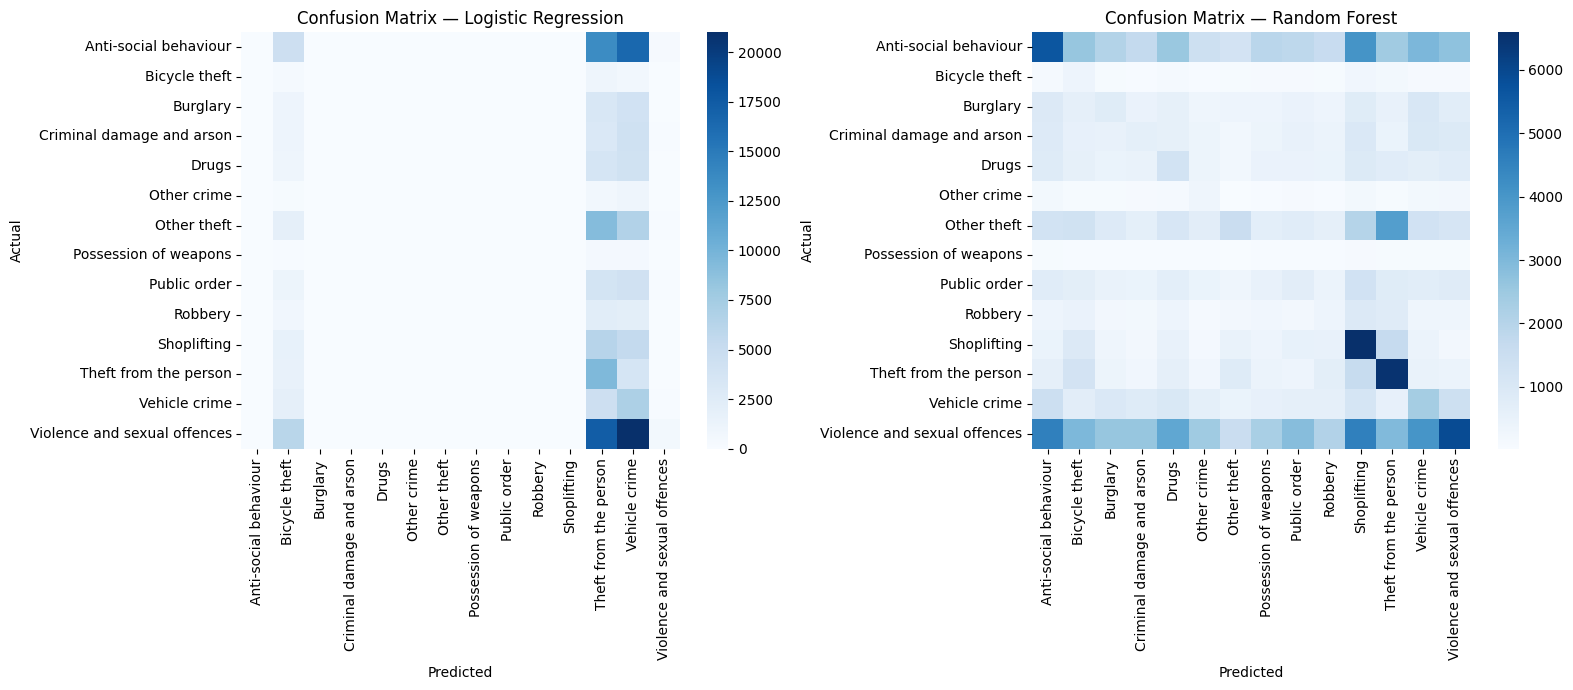

In [18]:
# ── Confusion matrices for LR, RF, and XGBoost (if available) ─────────────────
models_to_plot = [
    ('Logistic Regression', y_pred_lr),
    ('Random Forest', y_pred_rf),
]

# XGBoost will be appended here after Section 12 if available
# (placeholder — we check after XGBoost cell runs)

n_models = len(models_to_plot)
fig, axes = plt.subplots(1, n_models, figsize=(8 * n_models, 7))
if n_models == 1:
    axes = [axes]

for ax, (name, y_pred) in zip(axes, models_to_plot):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=False, cmap='Blues',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_, ax=ax)
    ax.set_title(f'Confusion Matrix — {name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

Reclaiming available RAM from used and un-needed objects to prevent a memory related crash with a free Google Colab runtime.

In [19]:
import gc

# Delete models and intermediate data no longer needed for feature importance or XGBoost
for var in ['lr', 'lr_raw', 'rf_raw', 'rf_smote', 'rf_ros',
            'X_train_scaled', 'X_test_scaled',
            'X_train_raw_scaled', 'X_test_raw_scaled',
            'X_smote', 'y_smote', 'X_ros', 'y_ros', 'X_sub', 'y_sub',
            'y_pred_lr', 'y_pred_lr_raw', 'y_pred_rf_raw',
            'y_pred_smote', 'y_pred_ros',
            'y_pred_random', 'y_pred_majority']:
    if var in globals():
        del globals()[var]

# Force garbage collection
gc.collect()

# Check memory freed (Colab-specific)
!free -h

               total        used        free      shared  buff/cache   available
Mem:            12Gi       7.4Gi       4.1Gi       2.0Mi       1.1Gi       4.9Gi
Swap:             0B          0B          0B


## 11. Feature importance and interpretability

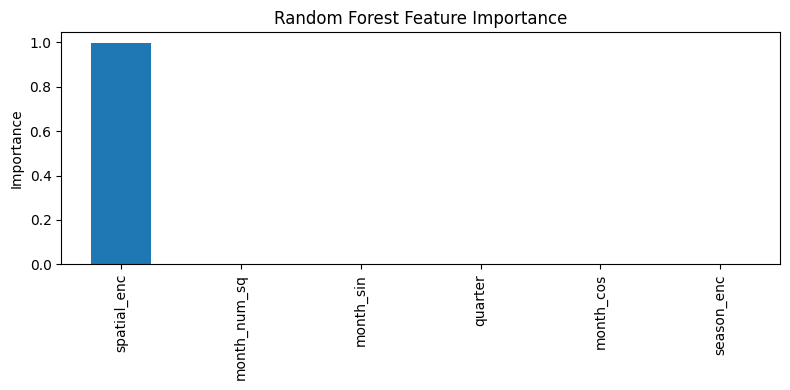

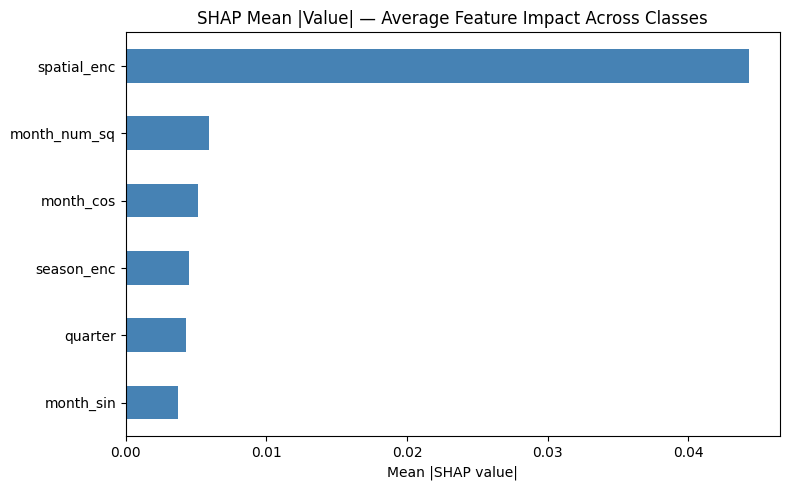

In [20]:
# Simple feature importance from Random Forest
importances = pd.Series(rf.feature_importances_, index=feature_cols_agg).sort_values(ascending=False)
plt.figure(figsize=(8, 4))
importances.plot(kind='bar')
plt.title('Random Forest Feature Importance')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

# Optional SHAP — robust to both old and new SHAP output formats
if SHAP_AVAILABLE:
    try:
        explainer = shap.TreeExplainer(rf)
        # Use a subsample of test data to avoid memory issues
        shap_sample = X_test.sample(n=min(1000, len(X_test)), random_state=42)
        shap_values = explainer.shap_values(shap_sample)

        # SHAP returns different formats for multi-class models:
        # - Older versions: a Python list of 2D arrays, one per class
        # - Newer versions (0.42+): a single 3D array (samples × features × classes)
        # We compute mean absolute SHAP value per feature, averaged across classes.
        if isinstance(shap_values, list):
            # Older format — mean |SHAP| across classes
            mean_abs_shap = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
        elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
            # Newer format — mean |SHAP| across samples and classes
            mean_abs_shap = np.abs(shap_values).mean(axis=(0, 2))
        else:
            # 2D single-class output (fallback)
            mean_abs_shap = np.abs(shap_values).mean(axis=0)

        shap_importance = pd.Series(mean_abs_shap, index=feature_cols_agg).sort_values(ascending=True)
        plt.figure(figsize=(8, 5))
        shap_importance.plot(kind='barh', color='steelblue')
        plt.title('SHAP Mean |Value| — Average Feature Impact Across Classes')
        plt.xlabel('Mean |SHAP value|')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print('SHAP could not be computed in this environment:', e)
else:
    print('SHAP not installed; skip this cell if needed.')

## 12. XGBoost model

**Note:** Unlike the previous cells, XGBoost uses `sample_weight` computed from class frequencies to ensure a fair comparison with the `class_weight='balanced'` approach used by LR and RF.

In [21]:
if XGBOOST_AVAILABLE:
    # Compute sample weights so XGBoost handles class imbalance fairly
    sw_train = compute_sample_weight('balanced', y_train)

    xgb = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.9,
        colsample_bytree=0.9,
        objective='multi:softmax',
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1
    )
    xgb.fit(X_train, y_train, sample_weight=sw_train)
    y_pred_xgb = xgb.predict(X_test)

    xgb_f1 = f1_score(y_test, y_pred_xgb, average='macro')
    print(f'XGBoost macro F1: {xgb_f1:.4f}')
    print()
    print(classification_report(y_test, y_pred_xgb, target_names=label_encoder.classes_))
else:
    y_pred_xgb = None
    print('XGBoost not available. This cell is optional.')

XGBoost macro F1: 0.0940

                              precision    recall  f1-score   support

       Anti-social behaviour       0.26      0.02      0.04     34856
               Bicycle theft       0.02      0.41      0.04      2024
                    Burglary       0.06      0.15      0.09      8554
   Criminal damage and arson       0.07      0.11      0.09      8669
                       Drugs       0.08      0.06      0.06      8932
                 Other crime       0.05      0.15      0.07      1995
                 Other theft       0.18      0.05      0.07     17827
       Possession of weapons       0.01      0.09      0.02      1016
                Public order       0.06      0.03      0.04      9245
                     Robbery       0.04      0.05      0.05      5248
                 Shoplifting       0.15      0.15      0.15     13473
       Theft from the person       0.28      0.41      0.33     14805
               Vehicle crime       0.11      0.21      0.14    

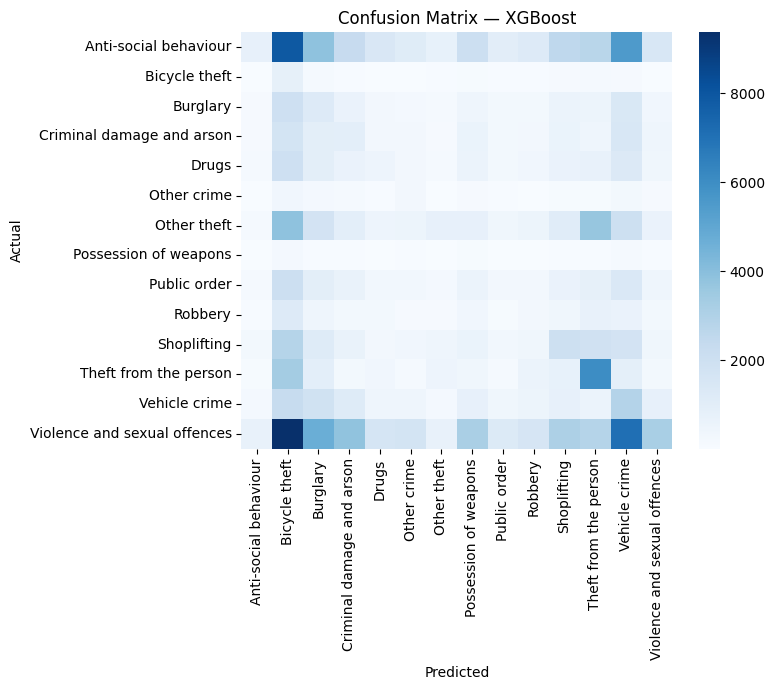

In [22]:
# ── XGBoost confusion matrix (separate cell so it runs after XGBoost trains) ──
if XGBOOST_AVAILABLE and y_pred_xgb is not None:
    plt.figure(figsize=(8, 7))
    cm_xgb = confusion_matrix(y_test, y_pred_xgb)
    sns.heatmap(cm_xgb, annot=False, cmap='Blues',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)
    plt.title('Confusion Matrix — XGBoost')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

## 12b. Multi-Layer Perceptron (MLP) — Neural Network for Tabular Data

Unlike CNNs (designed for images) or RNNs (designed for sequences), an MLP is a **feedforward neural network** suited to tabular data like ours. It learns non-linear relationships through stacked layers of neurons with activation functions.

This is included as an experimental comparison — MLPs rarely outperform well-tuned tree-based models on structured tabular data, but testing this is itself a valid finding.

In [23]:
# ── MLP (Multi-Layer Perceptron) using PyTorch ────────────────────────────────
if PYTORCH_AVAILABLE:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'Using device: {device}')

    # ── Scale features using the same scaler approach as LR ──────────────────
    scaler_mlp = StandardScaler()
    X_train_mlp = scaler_mlp.fit_transform(X_train)
    X_test_mlp  = scaler_mlp.transform(X_test)

    # ── Convert to PyTorch tensors ───────────────────────────────────────────
    X_train_t = torch.FloatTensor(X_train_mlp).to(device)
    y_train_t = torch.LongTensor(y_train.values).to(device)
    X_test_t  = torch.FloatTensor(X_test_mlp).to(device)
    y_test_t  = torch.LongTensor(y_test.values).to(device)

    # ── Compute class weights for balanced loss ──────────────────────────────
    class_counts = np.bincount(y_train.values, minlength=len(label_encoder.classes_))
    class_weights = 1.0 / (class_counts + 1e-6)       # inverse frequency
    class_weights = class_weights / class_weights.sum() * len(class_weights)  # normalise
    class_weights_t = torch.FloatTensor(class_weights).to(device)

    # ── Define the MLP architecture ──────────────────────────────────────────
    n_features = X_train_t.shape[1]
    n_classes  = len(label_encoder.classes_)

    class CrimeMLP(nn.Module):
        def __init__(self, n_in, n_out):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(n_in, 128),
                nn.ReLU(),
                nn.BatchNorm1d(128),
                nn.Dropout(0.3),

                nn.Linear(128, 64),
                nn.ReLU(),
                nn.BatchNorm1d(64),
                nn.Dropout(0.2),

                nn.Linear(64, 32),
                nn.ReLU(),

                nn.Linear(32, n_out)    # raw logits — no softmax (handled by CrossEntropyLoss)
            )

        def forward(self, x):
            return self.net(x)

    model = CrimeMLP(n_features, n_classes).to(device)

    # Print model summary
    total_params = sum(p.numel() for p in model.parameters())
    print(f'MLP architecture: {n_features} → 128 → 64 → 32 → {n_classes}')
    print(f'Total parameters: {total_params:,}')

    # ── Training setup ───────────────────────────────────────────────────────
    criterion = nn.CrossEntropyLoss(weight=class_weights_t)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )

    # DataLoader for mini-batch training (memory-efficient)
    train_dataset = TensorDataset(X_train_t, y_train_t)
    train_loader  = DataLoader(train_dataset, batch_size=2048, shuffle=True)

    # ── Training loop ────────────────────────────────────────────────────────
    EPOCHS = 50
    train_losses = []

    model.train()
    for epoch in range(EPOCHS):
        epoch_loss = 0.0
        n_batches  = 0

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            n_batches  += 1

        avg_loss = epoch_loss / n_batches
        train_losses.append(avg_loss)
        scheduler.step(avg_loss)

        if (epoch + 1) % 10 == 0:
            print(f'  Epoch {epoch+1:3d}/{EPOCHS}  loss: {avg_loss:.4f}')

    # ── Evaluation ───────────────────────────────────────────────────────────
    model.eval()
    with torch.no_grad():
        logits = model(X_test_t)
        y_pred_mlp = logits.argmax(dim=1).cpu().numpy()

    mlp_f1 = f1_score(y_test, y_pred_mlp, average='macro')
    print(f'\nMLP macro F1: {mlp_f1:.4f}')
    print()
    print(classification_report(y_test, y_pred_mlp, target_names=label_encoder.classes_))
else:
    y_pred_mlp = None
    mlp_f1 = None
    print('PyTorch not available. Skipping MLP.')

Using device: cuda
MLP architecture: 6 → 128 → 64 → 32 → 14
Total parameters: 12,078
  Epoch  10/50  loss: 2.6055
  Epoch  20/50  loss: 2.5958
  Epoch  30/50  loss: 2.5935
  Epoch  40/50  loss: 2.5907
  Epoch  50/50  loss: 2.5894

MLP macro F1: 0.0666

                              precision    recall  f1-score   support

       Anti-social behaviour       0.16      0.00      0.00     34856
               Bicycle theft       0.02      0.29      0.03      2024
                    Burglary       0.06      0.01      0.01      8554
   Criminal damage and arson       0.06      0.19      0.09      8669
                       Drugs       0.00      0.00      0.00      8932
                 Other crime       0.05      0.14      0.07      1995
                 Other theft       0.12      0.02      0.04     17827
       Possession of weapons       0.01      0.02      0.01      1016
                Public order       0.06      0.02      0.03      9245
                     Robbery       0.02      0

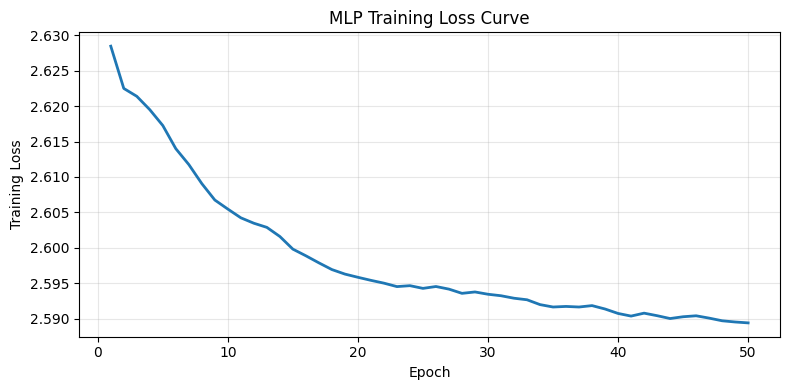

In [24]:
# ── MLP training loss curve ───────────────────────────────────────────────────
if PYTORCH_AVAILABLE and len(train_losses) > 0:
    plt.figure(figsize=(8, 4))
    plt.plot(range(1, len(train_losses)+1), train_losses, linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Training Loss')
    plt.title('MLP Training Loss Curve')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

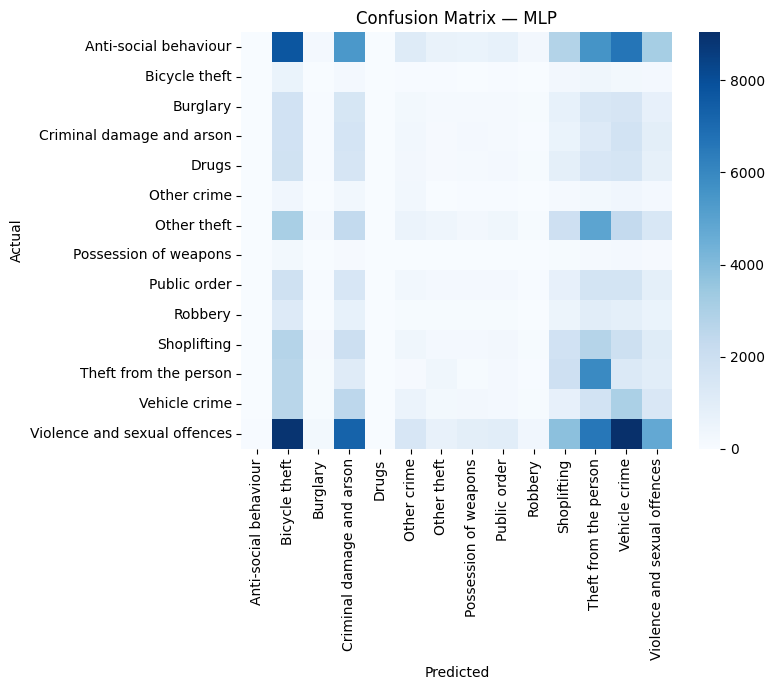

In [25]:
# ── MLP confusion matrix ──────────────────────────────────────────────────────
if PYTORCH_AVAILABLE and y_pred_mlp is not None:
    plt.figure(figsize=(8, 7))
    cm_mlp = confusion_matrix(y_test, y_pred_mlp)
    sns.heatmap(cm_mlp, annot=False, cmap='Blues',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)
    plt.title('Confusion Matrix — MLP')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

In [26]:
# ── Free MLP GPU/CPU memory ───────────────────────────────────────────────────
import gc

for var in ['model', 'X_train_t', 'y_train_t', 'X_test_t', 'y_test_t',
            'train_dataset', 'train_loader', 'X_train_mlp', 'X_test_mlp',
            'class_weights_t', 'criterion', 'optimizer', 'scheduler', 'logits']:
    if var in globals():
        del globals()[var]

if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()
print('MLP memory freed.')

MLP memory freed.


## Summary of results

In [27]:
# ── All results in one place ──────────────────────────────────────────────────
print('═' * 60)
print('HYPOTHESIS H1 — Models vs naive baselines')
print('═' * 60)
print(f'  Random baseline:          {random_f1:.4f}')
print(f'  Majority-class baseline:  {majority_f1:.4f}')
print(f'  Logistic Regression:      {lr_f1:.4f}')
print(f'  Random Forest:            {rf_f1:.4f}')
if XGBOOST_AVAILABLE and y_pred_xgb is not None:
    print(f'  XGBoost:                  {xgb_f1:.4f}')
if PYTORCH_AVAILABLE and mlp_f1 is not None:
    print(f'  MLP (Neural Network):     {mlp_f1:.4f}')

print()
print('═' * 60)
print('HYPOTHESIS H2 — Raw lat/lon vs aggregated spatial features')
print('═' * 60)
print(f'  LR  raw: {lr_raw_f1:.4f}  |  LR  agg: {lr_f1:.4f}  |  diff: {lr_f1 - lr_raw_f1:+.4f}')
print(f'  RF  raw: {rf_raw_f1:.4f}  |  RF  agg: {rf_f1:.4f}  |  diff: {rf_f1 - rf_raw_f1:+.4f}')

print()
print('═' * 60)
print('HYPOTHESIS H3 — Class imbalance mitigation')
print('═' * 60)
print(f'  RF (balanced_subsample):  {rf_f1:.4f}')
if smote_f1 is not None:
    print(f'  RF + SMOTE:               {smote_f1:.4f}')
print(f'  RF + RandomOverSampler:   {ros_f1:.4f}')
print('═' * 60)

════════════════════════════════════════════════════════════
HYPOTHESIS H1 — Models vs naive baselines
════════════════════════════════════════════════════════════
  Random baseline:          0.0598
  Majority-class baseline:  0.0279
  Logistic Regression:      0.0285
  Random Forest:            0.1370
  XGBoost:                  0.0940
  MLP (Neural Network):     0.0666

════════════════════════════════════════════════════════════
HYPOTHESIS H2 — Raw lat/lon vs aggregated spatial features
════════════════════════════════════════════════════════════
  LR  raw: 0.0252  |  LR  agg: 0.0285  |  diff: +0.0033
  RF  raw: 0.1871  |  RF  agg: 0.1370  |  diff: -0.0500

════════════════════════════════════════════════════════════
HYPOTHESIS H3 — Class imbalance mitigation
════════════════════════════════════════════════════════════
  RF (balanced_subsample):  0.1370
  RF + SMOTE:               0.0998
  RF + RandomOverSampler:   0.1171
════════════════════════════════════════════════════════════


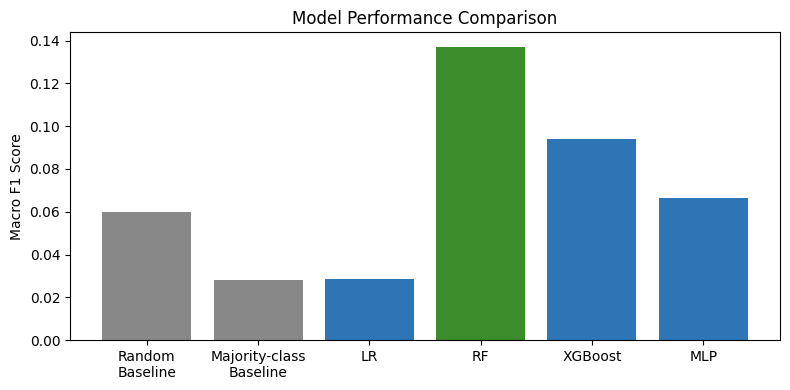

In [33]:
import matplotlib.pyplot as plt

models = ['Random\nBaseline', 'Majority-class\nBaseline', 'LR', 'RF', 'XGBoost', 'MLP']
scores = [random_f1, majority_f1, lr_f1, rf_f1, xgb_f1, mlp_f1]
colors = ['#888888', '#888888', '#2E75B6', '#3B8C2A', '#2E75B6', '#2E75B6']

plt.figure(figsize=(8, 4))
plt.bar(models, scores, color=colors)
plt.ylabel('Macro F1 Score')
plt.title('Model Performance Comparison')
plt.tight_layout()
plt.show()

## 13. Future work

The following is **not** part of the main notebook pipeline:

- Merge Office for National Statistics area-level socio-economic covariates by LSOA.
- Experiment with alternative spatial encoding strategies (target encoding, one-hot etc.).
- Re-train the model and check whether the added features improve macro F1 or minority-class recall.

Example sketch only (commented):

```python
# Future work 1: ONS socio-economic covariates as an additional feature signal
#
# ons = pd.read_csv('ons_lsoa_data.csv')
# merged = work_df.merge(ons, on='lsoa_code', how='left')

# Future work 2: Alternative spatial encoding strategies
# Target encoding replaces each LSOA with the mean target distribution
# observed in training, preserving spatial crime-type patterns.
#
# from category_encoders import TargetEncoder
# te = TargetEncoder(cols=['spatial_feature'])
# work_df['spatial_target_enc'] = te.fit_transform(
#     work_df['spatial_feature'], work_df['y']
# )
```

## 14. Save outputs

Save the trained model or the processed dataset if needed for later report writing.

In [29]:
import joblib

# Save to Google Drive so files persist after runtime disconnects
OUTPUT_DIR = '/content/drive/MyDrive/Colab Notebooks/urban_crime/saved_models'
os.makedirs(OUTPUT_DIR, exist_ok=True)

joblib.dump(rf, f'{OUTPUT_DIR}/random_forest_crime_model.joblib')
joblib.dump(label_encoder, f'{OUTPUT_DIR}/label_encoder.joblib')
joblib.dump(scaler, f'{OUTPUT_DIR}/standard_scaler.joblib')

print(f'Saved model artifacts to {OUTPUT_DIR}')

Saved model artifacts to /content/drive/MyDrive/Colab Notebooks/urban_crime/saved_models
